# NB - Traditional CNN Baseline

CNN truyền thống cơ bản để làm baseline so sánh.

- Không pretrained
- Không ResNet/DenseNet/EfficientNet/MobileNet
- Không YOLO
- Kiến trúc đơn giản
- Có learning curve, confusion matrix, classification report
- Có lưu model và zip kết quả


In [1]:
# =========================================
# 1. IMPORT
# =========================================

import os
import json
import shutil
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


2026-05-29 16:49:22.666411: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780073362.917677      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780073362.988381      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780073363.524373      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780073363.524423      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780073363.524425      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# =========================================
# 2. CONFIG
# =========================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATASET_PATH = "/kaggle/input/datasets/kimlonkkk/data10k-v2/split_dataset_backup_10k_v2"

IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 30

MODEL_NAME = "Traditional_CNN_Baseline"
OUT_DIR = f"/kaggle/working/{MODEL_NAME}_results"

os.makedirs(OUT_DIR, exist_ok=True)

AUTOTUNE = tf.data.AUTOTUNE


In [3]:
# =========================================
# 3. LOAD DATASET
# =========================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "train"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "val"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "test"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print("Num classes:", NUM_CLASSES)


Found 6890 files belonging to 5 classes.


I0000 00:00:1780073384.367509      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780073384.374092      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1475 files belonging to 5 classes.
Found 1482 files belonging to 5 classes.
Classes: ['blight', 'common_rust', 'gray_spot', 'healthy', 'not_corn_leaf']
Num classes: 5


In [4]:
# =========================================
# 4. NORMALIZE + PREFETCH
# =========================================

normalization_layer = layers.Rescaling(1.0 / 255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


In [5]:
# =========================================
# 5. DATA AUGMENTATION RẤT NHẸ
# =========================================
# Dataset của bạn đã augmentation sẵn nên ở đây để rất nhẹ.

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomZoom(0.02),
        layers.RandomTranslation(0.01, 0.01),
    ],
    name="data_augmentation"
)


In [6]:
# =========================================
# 6. BUILD TRADITIONAL CNN BASELINE
# =========================================
# Kiến trúc cố tình đơn giản để làm baseline.
# Không BatchNorm, không residual, không pretrained.

model = models.Sequential(
    [
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(8, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation="softmax")
    ],
    name=MODEL_NAME
)

model.summary()


Model: "Traditional_CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       524,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 525,877 (2.01 MB)

 Trainable params: 525,877 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# =========================================
# 7. COMPILE
# =========================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [8]:
# =========================================
# 8. CALLBACKS
# =========================================

checkpoint = ModelCheckpoint(
    filepath=f"{OUT_DIR}/{MODEL_NAME}_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint, earlystop, reduce_lr]


In [9]:
# =========================================
# 9. TRAIN
# =========================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/25


I0000 00:00:1780073392.532058     137 service.cc:152] XLA service 0x79fbf8006500 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780073392.532125     137 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780073392.532147     137 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780073393.028623     137 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/216 ━━━━━━━━━━━━━━━━━━━━ 18:53 5s/step - accuracy: 0.2812 - loss: 1.5982

I0000 00:00:1780073396.282101     137 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4479 - loss: 1.2803
Epoch 1: val_accuracy improved from None to 0.80203, saving model to /kaggle/working/Traditional_CNN_Baseline_results/Traditional_CNN_Baseline_best.keras

Epoch 1: finished saving model to /kaggle/working/Traditional_CNN_Baseline_results/Traditional_CNN_Baseline_best.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 22s 76ms/step - accuracy: 0.5495 - loss: 1.0658 - val_accuracy: 0.8020 - val_loss: 0.5679 - learning_rate: 0.0010
Epoch 2/25
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6924 - loss: 0.7255
Epoch 2: val_accuracy improved from 0.80203 to 0.84746, saving model to /kaggle/working/Traditional_CNN_Baseline_results/Traditional_CNN_Baseline_best.keras

Epoch 2: finished saving model to /kaggle/working/Traditional_CNN_Baseline_results/Traditional_CNN_Baseline_best.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.7218 - loss: 0.6643 - val_accuracy: 0.8475 - val_loss: 0.3940 - learning_rate: 0.0010
E

In [10]:
# =========================================
# 10. SAVE HISTORY
# =========================================

history_df = pd.DataFrame(history.history)

history_path = f"{OUT_DIR}/history.csv"
history_df.to_csv(history_path, index=False)

print("Saved:", history_path)
history_df.head()


Saved: /kaggle/working/Traditional_CNN_Baseline_results/history.csv


,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.549492,1.065804,0.802034,0.567897,0.001
1,0.721771,0.664283,0.847458,0.394000,0.001
2,0.789550,0.534734,0.877288,0.327737,0.001
3,0.807257,0.479278,0.894915,0.340142,0.001
4,0.838171,0.421533,0.900339,0.281951,0.001


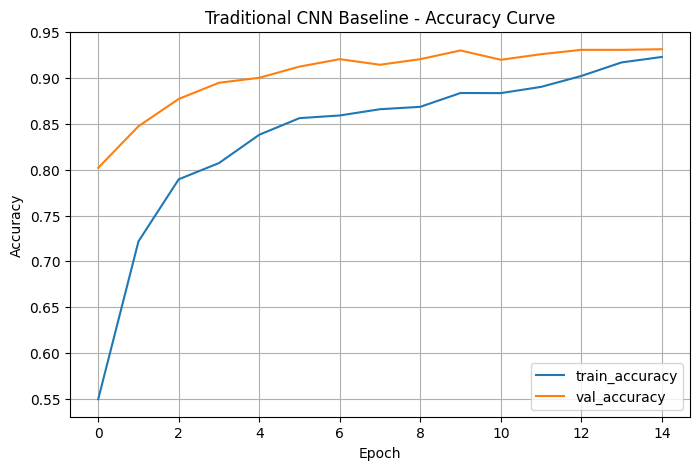

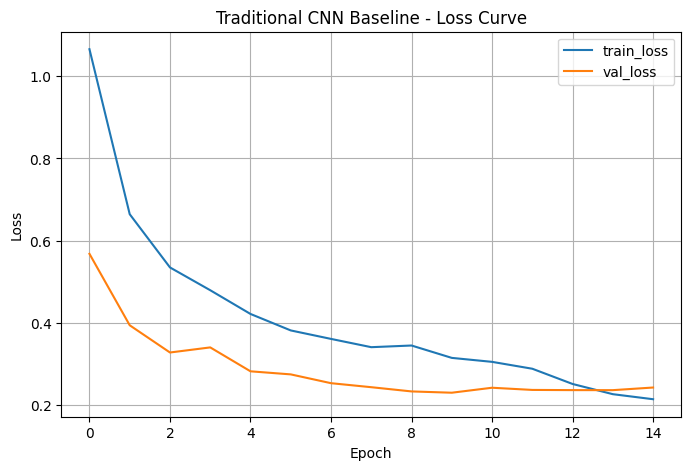

In [11]:
# =========================================
# 11. LEARNING CURVES
# =========================================

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("Traditional CNN Baseline - Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(f"{OUT_DIR}/accuracy_curve.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Traditional CNN Baseline - Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(f"{OUT_DIR}/loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()


In [12]:
# =========================================
# 12. EVALUATE TEST SET
# =========================================

test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.9265 - loss: 0.2887
Test Loss: 0.2887144684791565
Test Accuracy: 0.9264507293701172


In [13]:
# =========================================
# 13. PREDICT TEST SET
# =========================================

y_true = []

for _, y_batch in test_ds:
    y_true.extend(y_batch.numpy())

y_true = np.array(y_true)

pred_probs = model.predict(test_ds)
y_pred = np.argmax(pred_probs, axis=1)

print("y_true:", y_true.shape)
print("y_pred:", y_pred.shape)


47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
y_true: (1482,)
y_pred: (1482,)


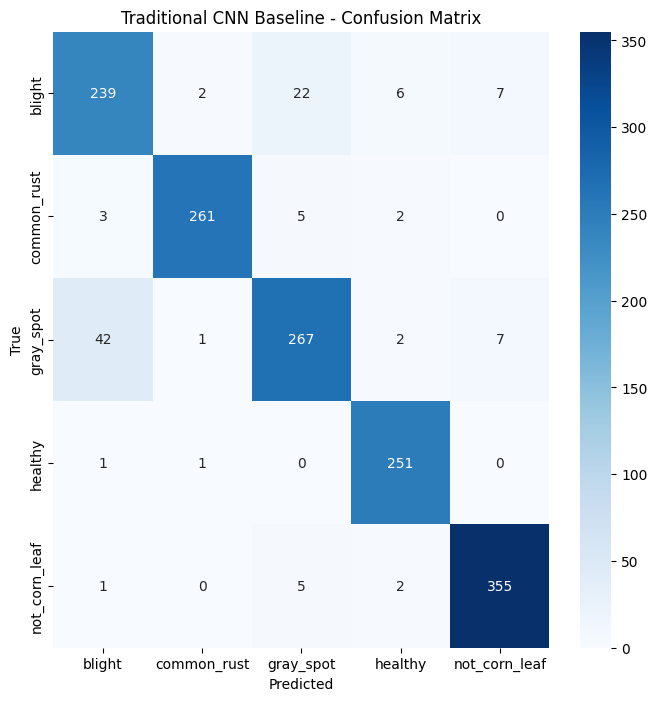

Saved: /kaggle/working/Traditional_CNN_Baseline_results/confusion_matrix.png


In [14]:
# =========================================
# 14. CONFUSION MATRIX
# =========================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("Traditional CNN Baseline - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

cm_path = f"{OUT_DIR}/confusion_matrix.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", cm_path)


In [15]:
# =========================================
# 15. CLASSIFICATION REPORT
# =========================================

report_text = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES
)

print(report_text)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

report_path = f"{OUT_DIR}/classification_report.csv"
report_df.to_csv(report_path)

print("Saved:", report_path)
report_df


               precision    recall  f1-score   support

       blight       0.84      0.87      0.85       276
  common_rust       0.98      0.96      0.97       271
    gray_spot       0.89      0.84      0.86       319
      healthy       0.95      0.99      0.97       253
not_corn_leaf       0.96      0.98      0.97       363

     accuracy                           0.93      1482
    macro avg       0.93      0.93      0.93      1482
 weighted avg       0.93      0.93      0.93      1482

Saved: /kaggle/working/Traditional_CNN_Baseline_results/classification_report.csv


,precision,recall,f1-score,support
blight,0.835664,0.865942,0.850534,276.000000
common_rust,0.984906,0.963100,0.973881,271.000000
gray_spot,0.892977,0.836991,0.864078,319.000000
healthy,0.954373,0.992095,0.972868,253.000000
not_corn_leaf,0.962060,0.977961,0.969945,363.000000
accuracy,0.926451,0.926451,0.926451,0.926451
macro avg,0.925996,0.927218,0.926261,1482.000000
weighted avg,0.926516,0.926451,0.926137,1482.000000


In [16]:
# =========================================
# 16. SAVE METRICS
# =========================================

metrics = {
    "model_name": MODEL_NAME,
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "classes": CLASS_NAMES,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "note": "Simple traditional CNN baseline, no pretrained model, no complex architecture."
}

metrics_path = f"{OUT_DIR}/metrics.json"

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4, ensure_ascii=False)

print("Saved:", metrics_path)


Saved: /kaggle/working/Traditional_CNN_Baseline_results/metrics.json


In [17]:
# =========================================
# 17. ZIP RESULTS
# =========================================

zip_path = f"/kaggle/working/{MODEL_NAME}_results.zip"

shutil.make_archive(
    zip_path.replace(".zip", ""),
    "zip",
    OUT_DIR
)

print("Saved:", zip_path)


Saved: /kaggle/working/Traditional_CNN_Baseline_results.zip


In [18]:
# =========================================
# 18. OPTIONAL - UPLOAD IMAGE FROM COMPUTER AND TEST
# =========================================

import io
from PIL import Image
from ipywidgets import FileUpload
from IPython.display import display

uploader = FileUpload(
    accept="image/*",
    multiple=False
)

display(uploader)


FileUpload(value=(), accept='image/*', description='Upload')

In [ ]:
# Run this cell after choosing an image above.

uploaded = uploader.value[0]

img = Image.open(
    io.BytesIO(uploaded["content"])
).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.show()

img_resized = img.resize((IMG_SIZE, IMG_SIZE))

x = np.array(img_resized).astype("float32") / 255.0
x = np.expand_dims(x, axis=0)

pred = model.predict(x)[0]

pred_idx = int(np.argmax(pred))
confidence = float(pred[pred_idx])

print("Prediction:", CLASS_NAMES[pred_idx])
print("Confidence:", f"{confidence:.4f}")

print("\nAll probabilities:")
for cls, prob in zip(CLASS_NAMES, pred):
    print(f"{cls:15s}: {prob:.4f}")
